# Worksheet-4 Solution
## Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification.

**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** April 01, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="
  https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


In [ ]:
import tensorflow as tf
import keras
import numpy as np

print(f"✅ TensorFlow version: {tf.__version__}")


✅ TensorFlow version: 2.21.0


# Task 1: Data Preparation
------------------------

### Loading the Data

-   Download the provided folder that contains the Devnagari digits dataset.

-   Use the **Python Imaging Library (PIL)** to load and read the image files form the dataset.

-   Convert the images into **Numpy arrays** and normalize them to a range of $0-1$.

-   Use the `train` folder for training and `test` for testing.

-   Extract the corresponding labels for each image.

 **Hints:**

 -   Ensure that the images are resized to a consistent shape (e.g., $28 \times 28$).

 -   Convert labels to **one-hot encoded** format for multi-class classification.

In [ ]:
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir = "DevanagariHandwrittenDigitDataset/Test/"

# Define image size
img_height, img_width = 28, 28


In [ ]:
import os
from PIL import Image


def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(
        os.listdir(folder)
    )  # Sorted class names (digit_0, digit_1, ...)
    class_map = {
        name: i for i, name in enumerate(class_names)
    }  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set:  (3000, 28, 28, 1),  Labels: (3000, 10)


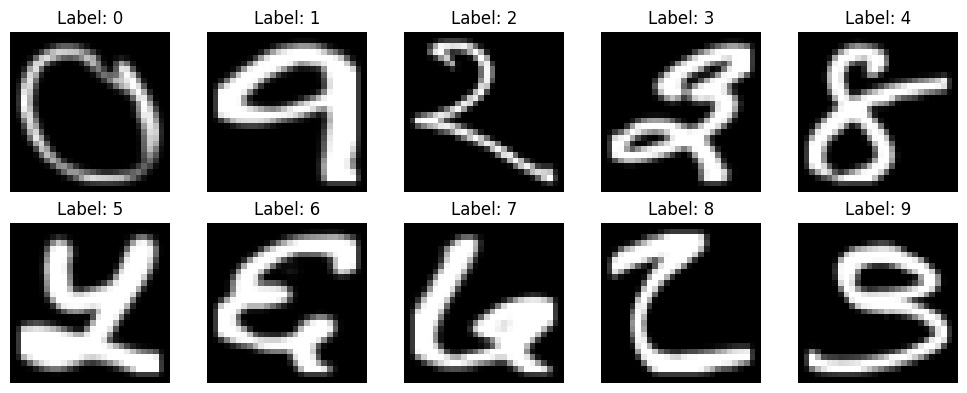

In [ ]:
import matplotlib.pyplot as plt
from keras.utils import to_categorical

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)  # (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set:  {x_test.shape},  Labels: {y_test.shape}")

# Visualize one image per class (0-9)
plt.figure(figsize=(10, 4))
true_labels = np.argmax(y_train, axis=1)  # convert one-hot back to integer labels

for digit in range(10):
    idx = np.where(true_labels == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Task 2: Build the FCN Model
---------------------------

### Model Architecture

-   Create a **Sequential** model using Keras.

-   Add **3 hidden layers** with the following neurons:

    1.  **1st hidden layer:** 64 neurons

    2.  **2nd hidden layer:** 128 neurons

    3.  **3rd hidden layer:** 256 neurons

-   Use **Sigmoid** activation functions for all hidden layers.

-   Add an **output layer** with **10 units** (since Devnagari digits have 10 classes) and a softmax activation function.

In [ ]:
num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),  # Flatten 28x28x1 → 784
        keras.layers.Dense(64, activation="sigmoid"),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(256, activation="sigmoid"),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model
---------------------------

### Model Compilation
- Choose an appropriate **optimizer** `(e.g., Adam)`, l**oss function** `(e.g., sparse_categorical_crossentropy)`, and **evalutional metric** `(e.g., accuracy)`.

In [ ]:
model.compile(
    optimizer="adam",  # Adam
    loss="categorical_crossentropy",  # Loss function for multi-class classification
    metrics=["accuracy"],  # Track accuracy during training
)
print("Model compiled successfully.")


Model compiled successfully.


Task 4: Train the Model
-----------------------

### Model Training

-   Use `model.fit()` to train the model. Set the **batch size to 128** and the number of **epochs to 20**.

-   Use **validation split of 0.2** to monitor model's performance on validation data.

-   Optionally, use callbacks such as `ModelCheckpoint` and `EarlyStopping` for saving the best model and avoiding overfitting.

In [ ]:
batch_size = 128
epochs = 20

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

# Shuffle the datasets
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)
x_train = x_train[indices]
y_train = y_train[indices]

# Train the model with callbacks and validation split
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,
    callbacks=callbacks,
)


Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4400 - loss: 1.8101 - val_accuracy: 0.7318 - val_loss: 1.0243
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8164 - loss: 0.6607 - val_accuracy: 0.8663 - val_loss: 0.4516
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8962 - loss: 0.3549 - val_accuracy: 0.9082 - val_loss: 0.3074
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9347 - loss: 0.2429 - val_accuracy: 0.9337 - val_loss: 0.2274
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.9487 - loss: 0.1850 - val_accuracy: 0.9490 - val_loss: 0.1860
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9603 - loss: 0.1446 - val_accuracy: 0.9584 - val_loss: 0.1587
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9664 - loss: 0.1188 - val_accuracy: 0.9627 - val_loss: 0.1394
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9738 - loss: 0.0970 - val_accuracy

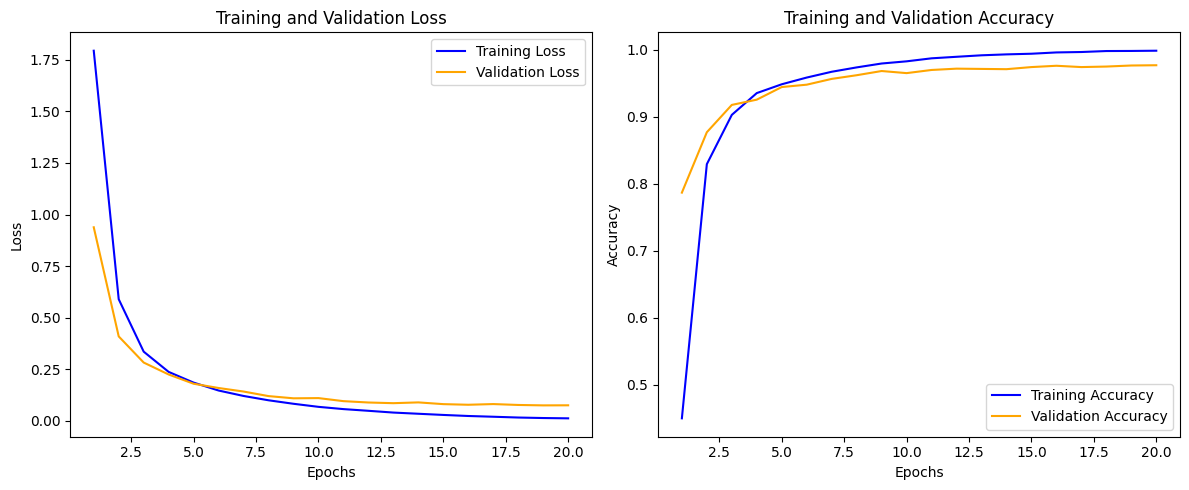

In [ ]:
# Extracting training and validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Extracting training and validation accuracy
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Training Loss", color="blue")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(
    range(1, len(train_acc) + 1), train_acc, label="Training Accuracy", color="blue"
)
plt.plot(
    range(1, len(val_acc) + 1), val_acc, label="Validation Accuracy", color="orange"
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Task 5: Evaluate the Model
--------------------------

### Model Evaluation

-   After training, evaluate the model using `model.evaluate()` on the test set to check the test accuracy and loss.

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_train, y_train, verbose=2)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


532/532 - 0s - 331us/step - accuracy: 0.9963 - loss: 0.0193
Test Loss:     0.0193
Test Accuracy: 0.9963


# Task 6: Save and Load the Model
-------------------------------

### Model Saving and Loading

-   Save the trained model to an `.h5` file using `model.save()`.

-   Load the saved model and re-evaluate its performance on the test set.

In [ ]:
# Save the trained model
path_to_model = "models/devnagari_fully_connected_model.h5"
model.save(path_to_model)
print("Model saved to 'devnagari_fully_connected_model.h5'")


Model saved to 'devnagari_fully_connected_model.h5'


In [ ]:
# Load the saved model
loaded_model = keras.models.load_model(path_to_model)
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_train, y_train, verbose=2)
print(f"Loaded Model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}")


Model loaded successfully.
532/532 - 0s - 483us/step - accuracy: 0.9963 - loss: 0.0193
Loaded Model — Test Loss: 0.0193 | Test Accuracy: 0.9963


# Task 7: Predictions
-------------------

### Making Predictions

-   Use `model.predict()` to make predictions on test images.

-   Convert the model's predicted probabilities to digit labels using `np.argmax()`.

In [ ]:
indices = np.arange(x_test.shape[0])
np.random.shuffle(indices)
x_test = x_test[indices]
y_test = y_test[indices]

# Predict on test data
predictions = model.predict(x_test)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image:      {np.argmax(y_test[0])}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step
Predicted label for first image: 8
True label for first image:      8


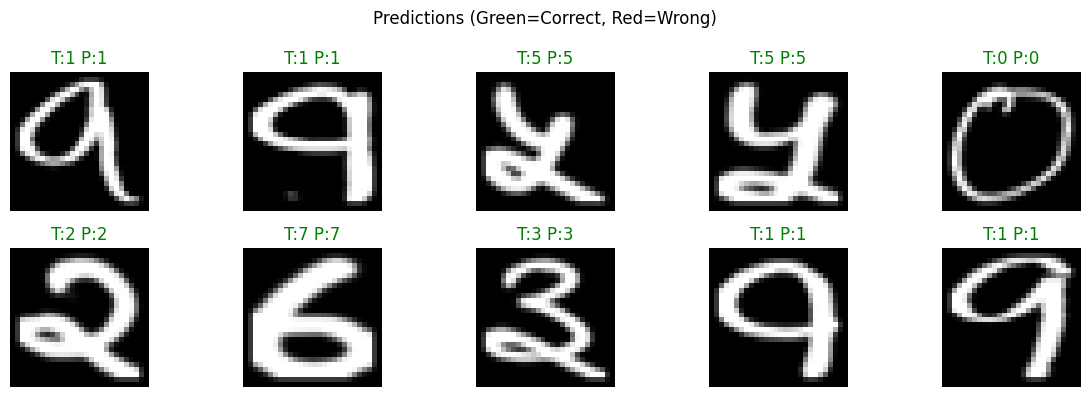

In [ ]:
# Visualise predictions on the first 10 test images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    true_label = np.argmax(y_test[i])
    pred_label = predicted_labels[i]
    colour = "green" if pred_label == true_label else "red"
    plt.title(f"T:{true_label} P:{pred_label}", color=colour)
    plt.axis("off")
plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()
